In [46]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

def offset_and_concat_by_file(dfs):
    adjusted = []
    running_max = 0
    for i, d in enumerate(dfs):
        d = d.copy()
        d["timestamp"] = d["timestamp"] + running_max
        adjusted.append(d)
        # set offset for next day/file
        running_max = d["timestamp"].max()
    return pd.concat(adjusted, ignore_index=True)


In [47]:
location = "./data/ROUND_3/"

day_m2 = pd.read_csv(location + 'prices_round_3_day_0.csv', sep=';')
day_m1 = pd.read_csv(location + 'prices_round_3_day_1.csv', sep=';')
day_0 = pd.read_csv(location + 'prices_round_3_day_2.csv', sep=';')

df = offset_and_concat_by_file([day_m2, day_m1, day_0])

df.head(20)

,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss
0,0,0,VEV_5400,22,25,NaN,NaN,NaN,NaN,24,25,NaN,NaN,NaN,NaN,23.0,0.0
1,0,0,VEV_6500,0,16,NaN,NaN,NaN,NaN,1,16,NaN,NaN,NaN,NaN,0.5,0.0
2,0,0,VEV_5500,8,25,NaN,NaN,NaN,NaN,9,25,NaN,NaN,NaN,NaN,8.5,0.0
3,0,0,VEV_5200,100,19,NaN,NaN,NaN,NaN,103,6,104.0,13.0,NaN,NaN,101.5,0.0
4,0,0,VEV_5300,52,6,51.0,19.0,NaN,NaN,54,25,NaN,NaN,NaN,NaN,53.0,0.0
5,0,0,VELVETFRUIT_EXTRACT,5247,67,NaN,NaN,NaN,NaN,5253,67,NaN,NaN,NaN,NaN,5250.0,0.0
6,0,0,VEV_4500,742,6,740.0,13.0,NaN,NaN,758,6,760.0,13.0,NaN,NaN,750.0,0.0
7,0,0,HYDROGEL_PACK,9992,15,9990.0,30.0,NaN,NaN,10008,15,10010.0,30.0,NaN,NaN,10000.0,0.0
8,0,0,VEV_5000,254,19,NaN,NaN,NaN,NaN,260,6,261.0,13.0,NaN,NaN,257.0,0.0
9,0,0,VEV_4000,1240,7,1237.0,24.0,NaN,NaN,1260,7,1263.0,24.0,NaN,NaN,1250.0,0.0


In [112]:
p1 = df[df["product"] == "VELVETFRUIT_EXTRACT"]
p2 = df[df["product"] == "HYDROGEL_PACK"]
VEV_6000 = df[df["product"] == "VEV_5500"]

p1.head()

,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss
5,0,0,VELVETFRUIT_EXTRACT,5247,67,NaN,NaN,NaN,NaN,5253,67,NaN,NaN,NaN,NaN,5250.0,0.0
13,0,100,VELVETFRUIT_EXTRACT,5248,69,NaN,NaN,NaN,NaN,5253,23,5254.0,46.0,NaN,NaN,5250.5,0.0
25,0,200,VELVETFRUIT_EXTRACT,5248,20,5247.0,40.0,NaN,NaN,5253,60,NaN,NaN,NaN,NaN,5250.5,0.0
47,0,300,VELVETFRUIT_EXTRACT,5248,24,5247.0,40.0,NaN,NaN,5253,64,NaN,NaN,NaN,NaN,5250.5,0.0
55,0,400,VELVETFRUIT_EXTRACT,5248,25,5247.0,37.0,NaN,NaN,5253,62,NaN,NaN,NaN,NaN,5250.5,0.0


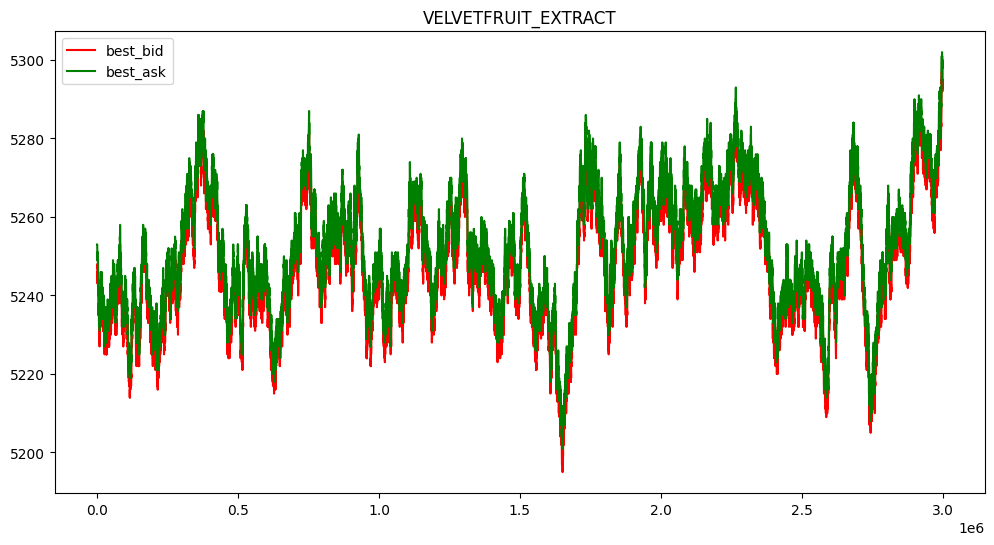

In [68]:
fig, ax = plt.subplots(figsize=(12, 6))
# ax.plot(p1["mid_price"], label="midprice")

timestamps = np.linspace(0, 3*1e6, 1000)
ax.plot(p1["timestamp"], p1["bid_price_1"], color="red", label="best_bid")
ax.plot(p1["timestamp"], p1["ask_price_1"], color="green", label="best_ask")
plt.legend()
plt.title(p1['product'].iloc[0])
plt.show()





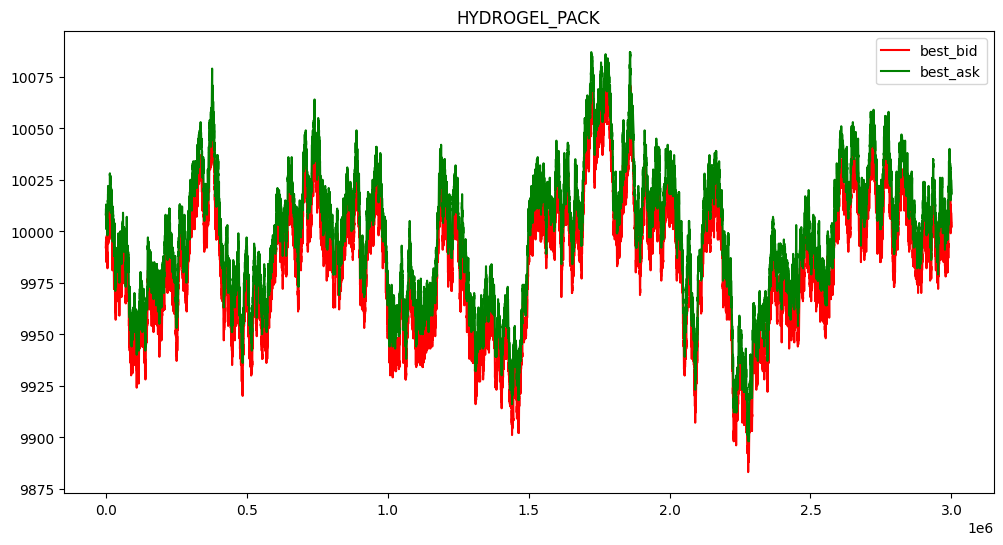

In [69]:
fig, ax = plt.subplots(figsize=(12, 6))
# ax.plot(p1["mid_price"], label="midprice")

timestamps = np.linspace(0, 3*1e6, 1000)
ax.plot(p2["timestamp"], p2["bid_price_1"], color="red", label="best_bid")
ax.plot(p2["timestamp"], p2["ask_price_1"], color="green", label="best_ask")
plt.legend()
plt.title(p2['product'].iloc[0])
plt.show()


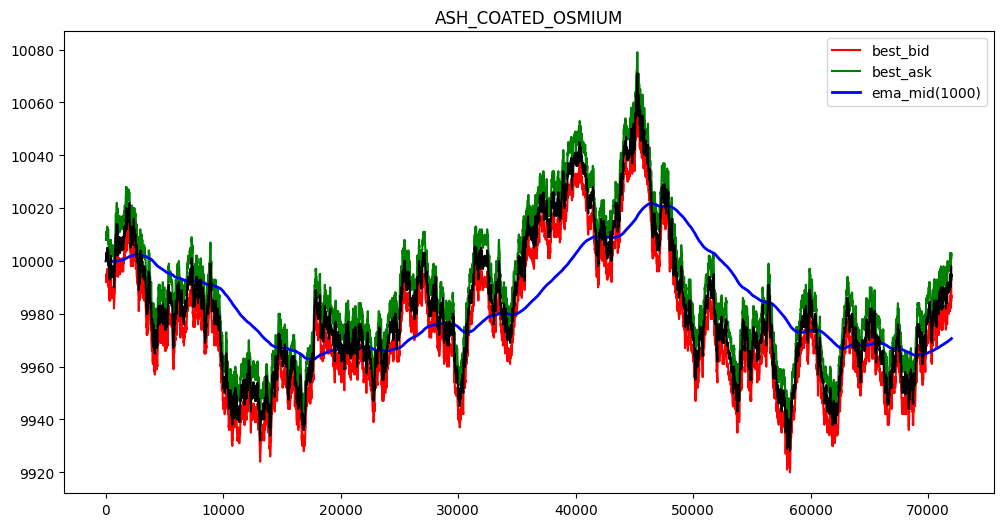

In [70]:
fig, ax = plt.subplots(figsize=(12, 6))
# ax.plot(p1["mid_price"], label="midprice")
maxt=6000
ax.plot(p2["bid_price_1"][:maxt], color="red", label="best_bid")
ax.plot(p2["ask_price_1"][:maxt], color="green", label="best_ask")

mid_price = (p2["bid_price_1"][:maxt] + p2["ask_price_1"][:maxt]) / 2
ema_span = 1000
ema_mid_price = mid_price.ewm(span=ema_span, adjust=False).mean()
ax.plot(ema_mid_price, color="blue", linewidth=2, label=f"ema_mid({ema_span})")
ax.plot(mid_price, color="black")

plt.legend()
plt.title("ASH_COATED_OSMIUM")
plt.show()



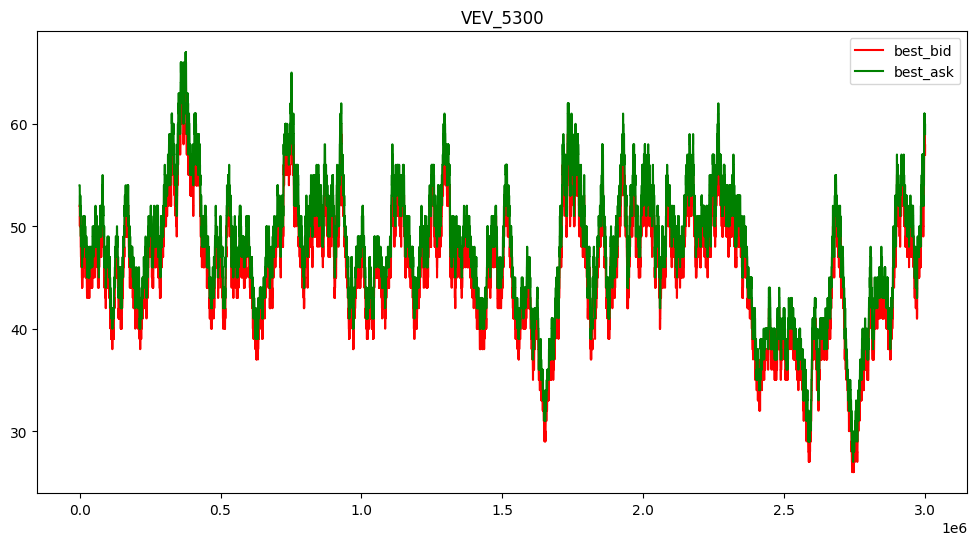

In [71]:
fig, ax = plt.subplots(figsize=(12, 6))
# ax.plot(p1["mid_price"], label="midprice")

timestamps = np.linspace(0, 3*1e6, 1000)
ax.plot(VEV_6000["timestamp"], VEV_6000["bid_price_1"], color="red", label="best_bid")
ax.plot(VEV_6000["timestamp"], VEV_6000["ask_price_1"], color="green", label="best_ask")
plt.legend()
plt.title(VEV_6000['product'].iloc[0])
plt.show()



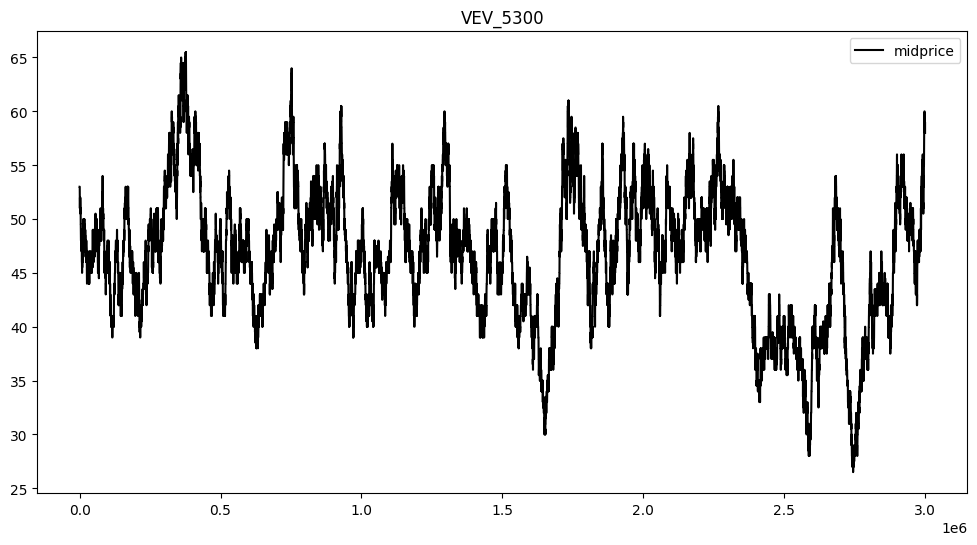

In [72]:
fig, ax = plt.subplots(figsize=(12, 6))
# ax.plot(p1["mid_price"], label="midprice")

timestamps = np.linspace(0, 3*1e6, 1000)
ax.plot(VEV_6000["timestamp"], VEV_6000["mid_price"], color="black", label="midprice")
plt.legend()
plt.title(VEV_6000['product'].iloc[0])
plt.show()


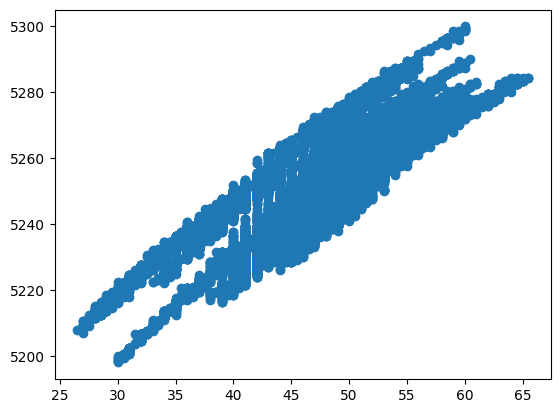

In [73]:
plt.scatter(VEV_6000["mid_price"], p1['mid_price'])

In [228]:
import pandas as pd
import numpy as np
from scipy.stats import norm
from scipy.optimize import newton

# --- 1. Core Logic (r=0, T in days) ---

def bs_call_price(S, K, T, sigma_daily):
    """BS Price where T is in days and sigma is daily volatility."""
    if sigma_daily <= 0 or T <= 0:
        return max(0, S - K)
    # Note: with r=0, d1/d2 simplify significantly
    d1 = (np.log(S / K) + (0.5 * sigma_daily**2) * T) / (sigma_daily * np.sqrt(T))
    d2 = d1 - sigma_daily * np.sqrt(T)
    return S * norm.cdf(d1) - K * norm.cdf(d2)

def bs_vega_daily(S, K, T, sigma_daily):
    """Vega with respect to daily volatility."""
    d1 = (np.log(S / K) + (0.5 * sigma_daily**2) * T) / (sigma_daily * np.sqrt(T))
    return S * norm.pdf(d1) * np.sqrt(T)

def find_annualized_iv(row):
    S, K, market_price = row['stock_mid'], row['strike'], row['mid_price']
    T = 7  # Fixed 7 days
    
    if market_price <= max(0, S - K):
        return 0.0
    
    # We solve for DAILY volatility first
    try:
        daily_vol = newton(
            lambda sig: bs_call_price(S, K, T, sig) - market_price, 
            x0=0.02, # Start with a 2% daily move guess
            fprime=lambda sig: bs_vega_daily(S, K, T, sig),
            tol=1e-5
        )
        # Convert daily volatility to Annualized IV
        return daily_vol 
    except:
        return np.nan

# --- 2. Data Processing ---

# Assuming 'df' is your original DataFrame
# 1. Split Stock and Options
stock_df = df[df['product'] == 'VELVETFRUIT_EXTRACT'][['timestamp', 'mid_price']]
stock_df.columns = ['timestamp', 'stock_mid']

option_df = df[df['product'].str.contains('VEV_')].copy()

# 2. Extract Strike from product name (e.g., 'VEV_6000' -> 6000)
option_df['strike'] = option_df['product'].str.extract(r'_(\d+)').astype(float)

# 3. Merge to align stock price with option price at each timestamp
merged = pd.merge(option_df, stock_df, on='timestamp')

# 4. Calculate Moneyness: log(K/S) / sqrt(TTE)
# TTE is 7 days as requested
merged['moneyness'] = np.log(merged['strike'] / merged['stock_mid']) / np.sqrt(7)

# 5. Calculate IV (Annualized)
merged['implied_vol'] = merged.apply(find_annualized_iv, axis=1)

# Display results
print(merged[['timestamp', 'product', 'strike', 'stock_mid', 'mid_price', 'moneyness', 'implied_vol']])

/Users/mathijs/prosperity4/.venv/lib/python3.12/site-packages/scipy/optimize/_zeros_py.py:327: RuntimeWarning: overflow encountered in scalar divide
  newton_step = fval / fder
/var/folders/sn/lj91sdfx3kn8_bc114w6rmg40000gn/T/ipykernel_18063/4192608268.py:19: RuntimeWarning: invalid value encountered in scalar divide
  d1 = (np.log(S / K) + (0.5 * sigma_daily**2) * T) / (sigma_daily * np.sqrt(T))
/var/folders/sn/lj91sdfx3kn8_bc114w6rmg40000gn/T/ipykernel_18063/4192608268.py:19: RuntimeWarning: overflow encountered in scalar power
  d1 = (np.log(S / K) + (0.5 * sigma_daily**2) * T) / (sigma_daily * np.sqrt(T))


        timestamp   product  strike  stock_mid  mid_price  moneyness  \
0               0  VEV_5400  5400.0     5250.0       23.0   0.010648   
1               0  VEV_6500  6500.0     5250.0        0.5   0.080723   
2               0  VEV_5500  5500.0     5250.0        8.5   0.017583   
3               0  VEV_5200  5200.0     5250.0      101.5  -0.003617   
4               0  VEV_5300  5300.0     5250.0       53.0   0.003583   
...           ...       ...     ...        ...        ...        ...   
300035    2999700  VEV_6000  6000.0     5295.5        0.5   0.047209   
300036    2999700  VEV_4500  4500.0     5295.5      795.5  -0.061525   
300037    2999700  VEV_5400  5400.0     5295.5       20.0   0.007386   
300038    2999700  VEV_6500  6500.0     5295.5        0.5   0.077462   
300039    2999700  VEV_5500  5500.0     5295.5        7.0   0.014321   

        implied_vol  
0          0.013423  
1          0.029962  
2          0.013421  
3          0.013386  
4          0.013539  
...

In [58]:
merged.head()

,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,...,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss,strike,stock_mid,moneyness,implied_vol
0,0,0,VEV_5400,22,25,NaN,NaN,NaN,NaN,24,...,NaN,NaN,NaN,NaN,23.0,0.0,5400.0,5250.0,0.010648,0.013423
1,0,0,VEV_6500,0,16,NaN,NaN,NaN,NaN,1,...,NaN,NaN,NaN,NaN,0.5,0.0,6500.0,5250.0,0.080723,0.029962
2,0,0,VEV_5500,8,25,NaN,NaN,NaN,NaN,9,...,NaN,NaN,NaN,NaN,8.5,0.0,5500.0,5250.0,0.017583,0.013421
3,0,0,VEV_5200,100,19,NaN,NaN,NaN,NaN,103,...,104.0,13.0,NaN,NaN,101.5,0.0,5200.0,5250.0,-0.003617,0.013386
4,0,0,VEV_5300,52,6,51.0,19.0,NaN,NaN,54,...,NaN,NaN,NaN,NaN,53.0,0.0,5300.0,5250.0,0.003583,0.013539


In [227]:
# 1. Ensure outliers are removed
filtered_df = merged[merged['implied_vol'] > 0].copy()

# 2. Setup the plot
plt.figure(figsize=(11, 7))

# Get sorted unique products (e.g., VEV_5900, VEV_6000...)
products = sorted(filtered_df['product'].unique())

# Generate a color map for the number of products you have
colors = plt.cm.viridis(np.linspace(0, 1, len(products)))

# 3. Loop through each product and plot separately to create legend entries
for product, color in zip(products, colors):
    subset = filtered_df[filtered_df['product'] == product]
    plt.scatter(
        subset['moneyness'], 
        subset['implied_vol'], 
        color=color, 
        label=product,   # This label is used for the legend
        alpha=0.6, 
        s=25
    )

# 4. Final touches
plt.xlabel(r'Moneyness $\left( \frac{\ln(K/S)}{\sqrt{T}} \right)$')
plt.ylabel('Annualized Implied Volatility ($\sigma$)')
plt.title('Implied Volatility Smile by Strike Price (T=7 Days)')
plt.grid(True, linestyle='--', alpha=0.4)

# Place legend outside the plot for better readability
plt.legend(title="Option Strike", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

plt.show()

<>:27: SyntaxWarning: invalid escape sequence '\s'
<>:27: SyntaxWarning: invalid escape sequence '\s'
/var/folders/sn/lj91sdfx3kn8_bc114w6rmg40000gn/T/ipykernel_18063/1120375187.py:27: SyntaxWarning: invalid escape sequence '\s'
  plt.ylabel('Annualized Implied Volatility ($\sigma$)')


KeyError: 'implied_vol'

<>:39: SyntaxWarning: invalid escape sequence '\s'
<>:39: SyntaxWarning: invalid escape sequence '\s'
/var/folders/sn/lj91sdfx3kn8_bc114w6rmg40000gn/T/ipykernel_18063/878609275.py:39: SyntaxWarning: invalid escape sequence '\s'
  plt.ylabel('Annualized Implied Volatility ($\sigma$)')


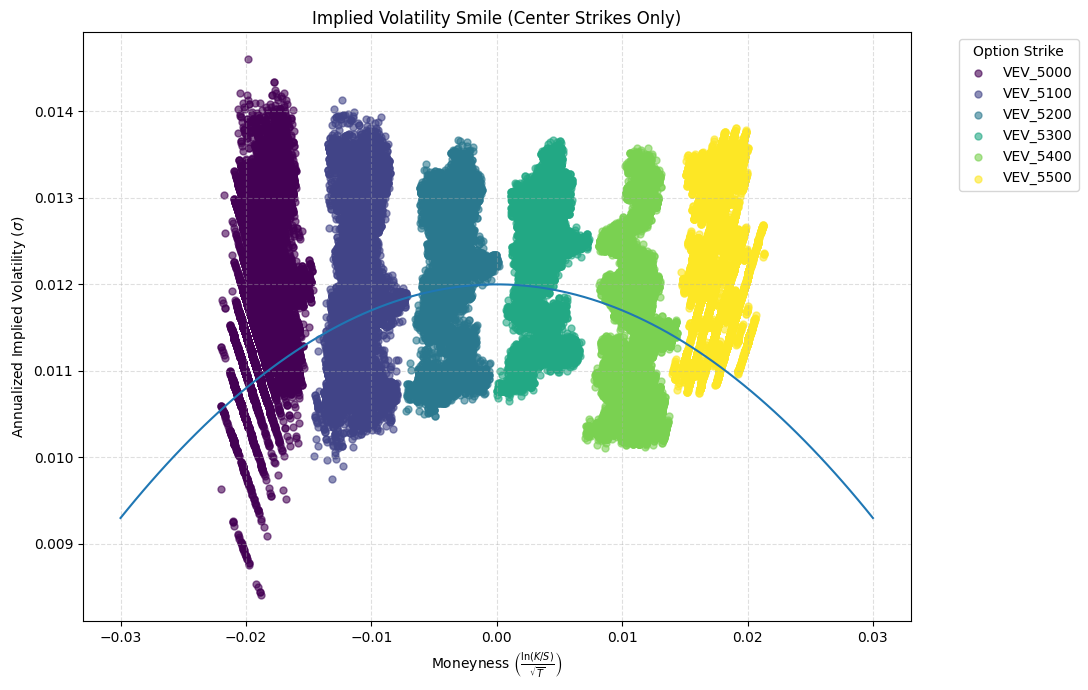

In [235]:

# 1. Ensure outliers are removed
filtered_df = merged[merged['implied_vol'] > 0].copy()

# --- NEW: Filter out the extreme strikes ---
strikes_to_exclude = ['VEV_4500', 'VEV_6000', 'VEV_6500']
filtered_df = filtered_df[~filtered_df['product'].isin(strikes_to_exclude)]
# ------------------------------------------

# 2. Setup the plot
plt.figure(figsize=(11, 7))

# Get sorted unique products (This will now naturally exclude the ones we filtered out)
products = sorted(filtered_df['product'].unique())

# Generate a color map for the number of products you have
colors = plt.cm.viridis(np.linspace(0, 1, len(products)))

# 3. Loop through each product and plot separately to create legend entries
for product, color in zip(products, colors):
    subset = filtered_df[filtered_df['product'] == product]
    plt.scatter(
        subset['moneyness'], 
        subset['implied_vol'], 
        color=color, 
        label=product,   
        alpha=0.6, 
        s=25
    )

# 4. Final touches
def manual_fit(moneyness):
    return 0.012 - 3 * moneyness**2

x = np.linspace(-0.03, 0.03, 100)
volt = manual_fit(x)

plt.plot(x, volt)
plt.xlabel(r'Moneyness $\left( \frac{\ln(K/S)}{\sqrt{T}} \right)$')
plt.ylabel('Annualized Implied Volatility ($\sigma$)')
plt.title('Implied Volatility Smile (Center Strikes Only)')
plt.grid(True, linestyle='--', alpha=0.4)

# Place legend outside the plot for better readability
plt.legend(title="Option Strike", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

plt.show()

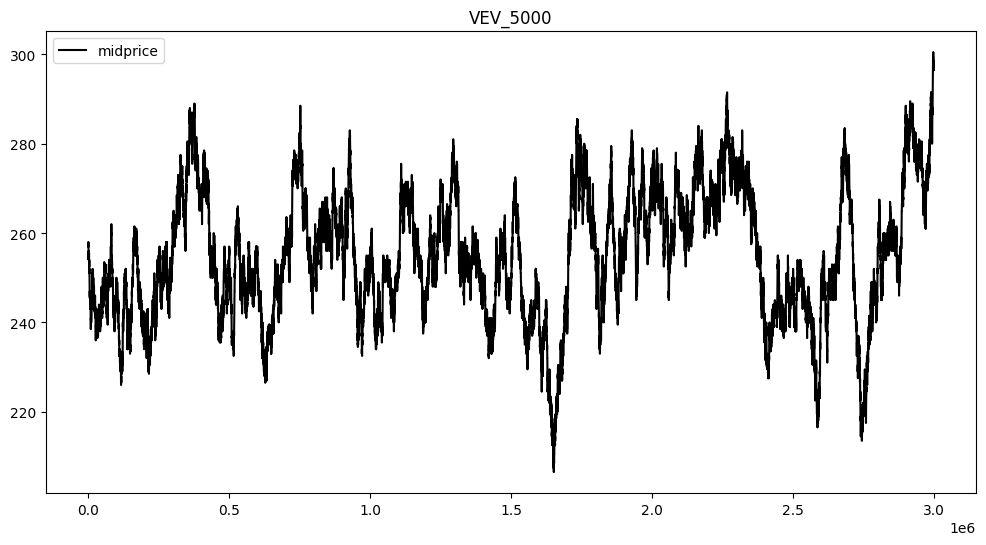

In [87]:
fig, ax = plt.subplots(figsize=(12, 6))
# ax.plot(p1["mid_price"], label="midprice")

timestamps = np.linspace(0, 3*1e6, 1000)
ax.plot(VEV_6000["timestamp"], VEV_6000["mid_price"], color="black", label="midprice")
plt.legend()
plt.title(VEV_6000['product'].iloc[0])
plt.show()

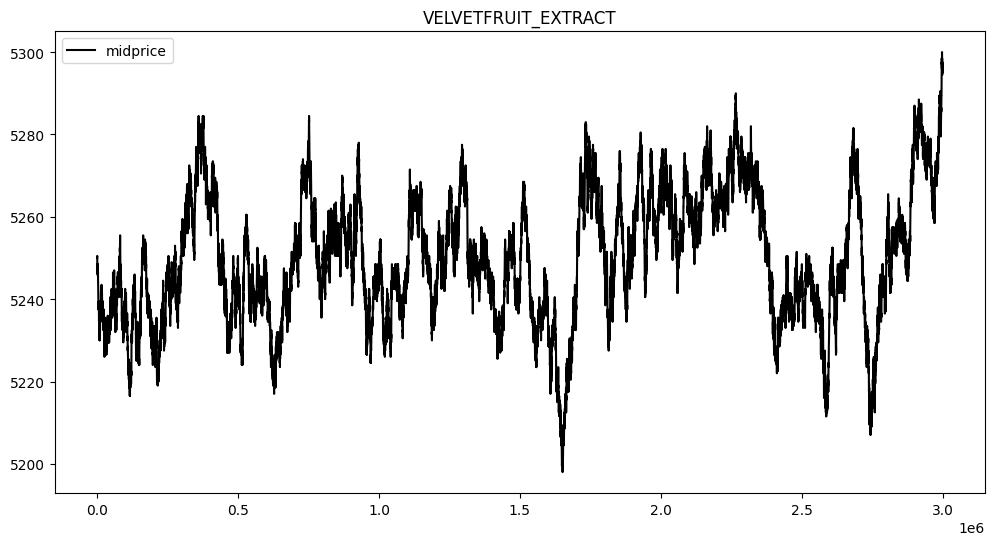

In [88]:
fig, ax = plt.subplots(figsize=(12, 6))
# ax.plot(p1["mid_price"], label="midprice")

timestamps = np.linspace(0, 3*1e6, 1000)
ax.plot(p1["timestamp"], p1["mid_price"], color="black", label="midprice")
plt.legend()
plt.title(p1['product'].iloc[0])
plt.show()

In [216]:
S =  p1["mid_price"]
K = 5200
sigma = 0.012
T = 9-p1["timestamp"]/1000000
d1 = (np.log(S/K) + sigma**2/2*T)/(sigma*np.sqrt(T))

d2 = d1 - sigma*np.sqrt(T)

# Use .cdf() to get the actual probability values
C = S * norm.cdf(d1) - K * norm.cdf(d2)

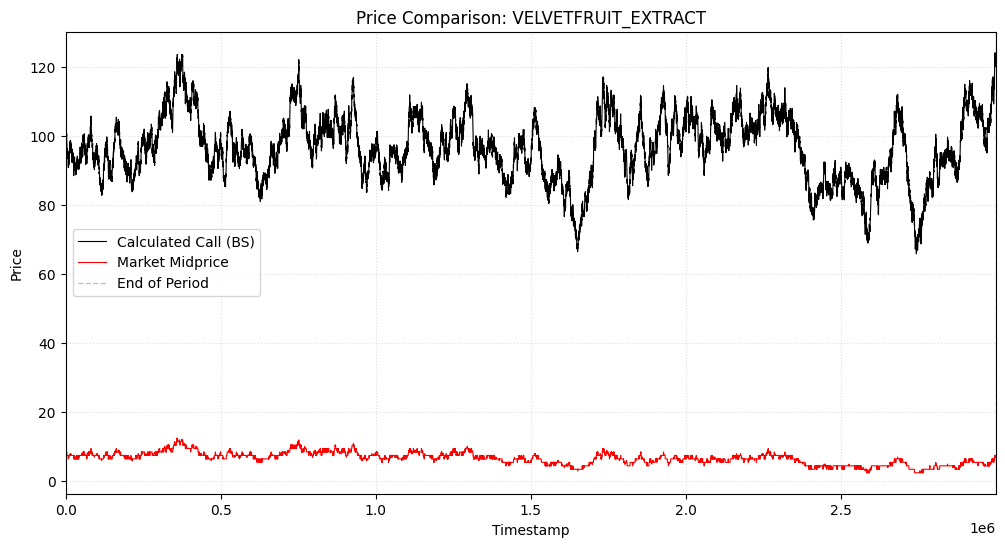

In [217]:
fig, ax = plt.subplots(figsize=(12, 6))

# Define your max timestamp
max_ts = p1["timestamp"].max()

# 1. Make the lines thinner using linewidth (lw)
# I suggest 0.8 or 1 for a 'high-tech' feel
ax.plot(VEV_6000["timestamp"], C, color="black", label="Calculated Call (BS)", lw=0.8)
ax.plot(VEV_6000["timestamp"], VEV_6000["mid_price"], color="red", label="Market Midprice", lw=0.8)

# 2. Set the x-axis limit to the max timestamp
ax.set_xlim(p1["timestamp"].min(), max_ts)

# 3. Optional: Add a vertical line at the max timestamp for visual emphasis
ax.axvline(x=max_ts, color='gray', linestyle='--', lw=1, alpha=0.5, label="End of Period")

plt.legend()
plt.title(f"Price Comparison: {p1['product'].iloc[0]}")
plt.xlabel("Timestamp")
plt.ylabel("Price")

# Add a grid for easier readability with thin lines
ax.grid(True, which='both', linestyle=':', alpha=0.4)

plt.show()

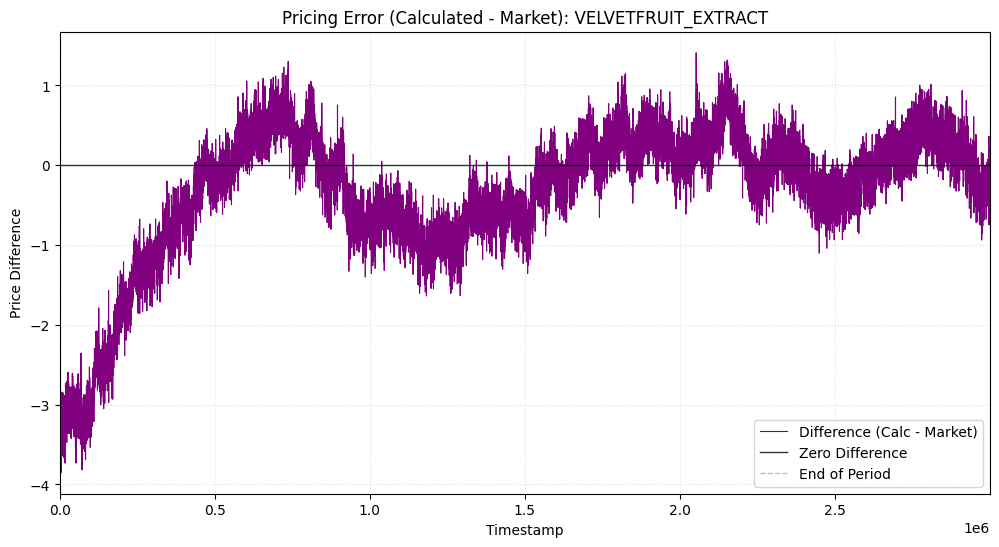

In [225]:
option_strikes = [5000, 5100, 5200, 5300, 5400, 5500]

S =  p1["mid_price"]
K = 5400
sigma = 0.0111
T = 9-p1["timestamp"]/1000000
d1 = (np.log(S/K) + sigma**2/2*T)/(sigma*np.sqrt(T))

d2 = d1 - sigma*np.sqrt(T)

# Use .cdf() to get the actual probability values
C = S * norm.cdf(d1) - K * norm.cdf(d2)

fig, ax = plt.subplots(figsize=(12, 6))

# Define your max timestamp
max_ts = p1["timestamp"].max()

# 1. Calculate the difference (Calculated Price - Market Price)
# If C is a numpy array or pandas Series of the same length, this works perfectly.
option = df[df["product"] == "VEV_5400"]
price_difference = np.array(C) - option["mid_price"].values

# 2. Plot the difference
ax.plot(option["timestamp"], price_difference, color="purple", label="Difference (Calc - Market)", lw=0.8)

# 3. Add a horizontal line at 0 for visual reference
ax.axhline(0, color='black', linestyle='-', lw=1, alpha=0.8, label="Zero Difference")

# 4. Set the x-axis limit to the max timestamp
ax.set_xlim(p1["timestamp"].min(), max_ts)

# 5. Add a vertical line at the max timestamp for visual emphasis
ax.axvline(x=max_ts, color='gray', linestyle='--', lw=1, alpha=0.5, label="End of Period")

plt.legend()
plt.title(f"Pricing Error (Calculated - Market): {p1['product'].iloc[0]}")
plt.xlabel("Timestamp")
plt.ylabel("Price Difference")

# Add a grid for easier readability with thin lines
ax.grid(True, which='both', linestyle=':', alpha=0.4)

plt.show()

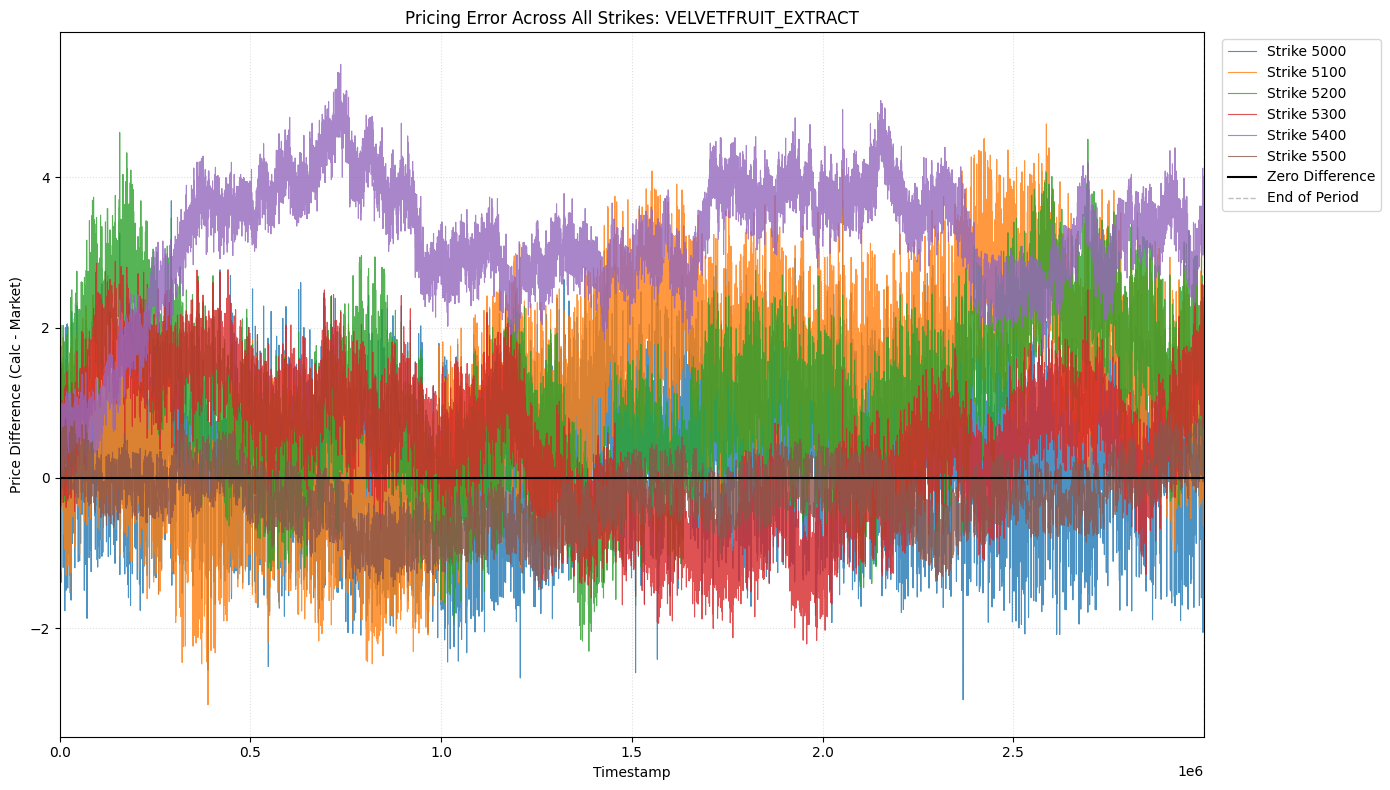

In [219]:
import numpy as np
import matplotlib.pyplot as plt
# Make sure to import your custom norm_cdf here if you are using it instead of scipy!

option_strikes = [5000, 5100, 5200, 5300, 5400, 5500]

# Underlying price and time remain the same for all options
S = p1["mid_price"]
T = 9 - p1["timestamp"] / 1000000
sigma = 0.012

fig, ax = plt.subplots(figsize=(14, 8))
max_ts = p1["timestamp"].max()

# Loop through each strike price
for K in option_strikes:
    # 1. Calculate Black-Scholes d1, d2, and Call Price (C) for the current Strike
    d1 = (np.log(S / K) + (sigma**2 / 2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    C = S * norm.cdf(d1) - K * norm.cdf(d2)
    
    # 2. Get the market data for this specific option
    product_name = f"VEV_{K}"
    option = df[df["product"] == product_name]
    
    # 3. Calculate the difference (Calc - Market)
    price_difference = np.array(C) - option["mid_price"].values
    
    # 4. Plot the difference for this strike
    ax.plot(option["timestamp"], price_difference, label=f"Strike {K}", lw=0.8, alpha=0.8)

# Add reference lines
ax.axhline(0, color='black', linestyle='-', lw=1.5, alpha=1.0, label="Zero Difference")
ax.set_xlim(p1["timestamp"].min(), max_ts)
ax.axvline(x=max_ts, color='gray', linestyle='--', lw=1, alpha=0.5, label="End of Period")

# Formatting
# Move the legend slightly outside the plot so it doesn't cover your data
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left')
plt.title(f"Pricing Error Across All Strikes: {p1['product'].iloc[0]}")
plt.xlabel("Timestamp")
plt.ylabel("Price Difference (Calc - Market)")
ax.grid(True, which='both', linestyle=':', alpha=0.4)

plt.tight_layout() # Ensures the external legend fits in the image
plt.show()

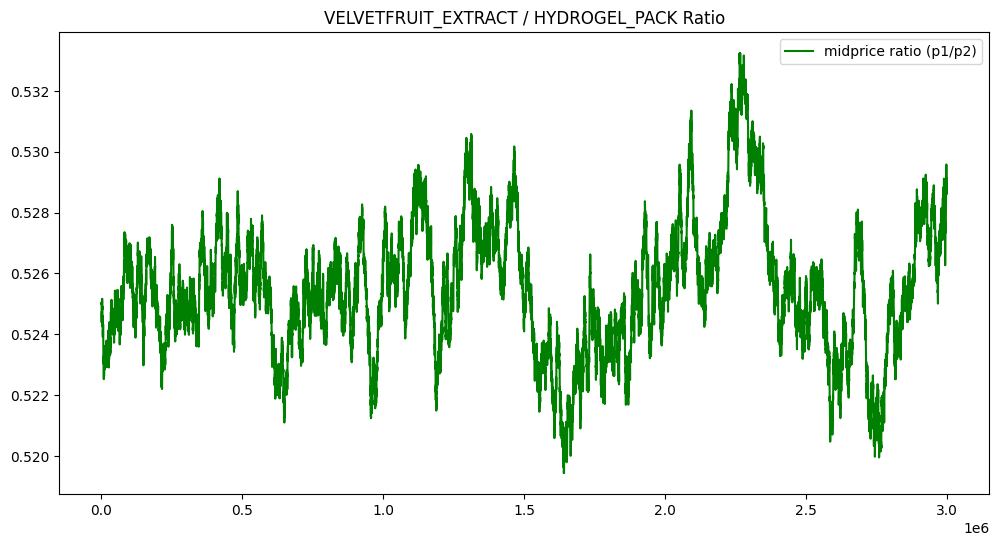

In [197]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Merge p1 and p2 on the 'timestamp' column.
# The inner join ensures we only keep timestamps present in both dataframes.
merged = pd.merge(
    p1[['timestamp', 'mid_price']], 
    p2[['timestamp', 'mid_price']], 
    on='timestamp', 
    suffixes=('_1', '_2')
)

# 2. Setup the plot
fig, ax = plt.subplots(figsize=(12, 6))

# 3. Calculate the ratio using the aligned mid_prices
merged['ratio'] = merged['mid_price_1'] / merged['mid_price_2']

# 4. Plot using the common timestamps
ax.plot(merged['timestamp'], merged['ratio'], color="green", label="midprice ratio (p1/p2)")

plt.legend()
plt.title(f"{p1['product'].iloc[0]} / {p2['product'].iloc[0]} Ratio")
plt.show()

In [198]:
merged.head()

,timestamp,mid_price_1,mid_price_2,ratio
0,0,5250.0,10000.0,0.525000
1,100,5250.5,10000.0,0.525050
2,200,5250.5,10003.0,0.524893
3,300,5250.5,10002.0,0.524945
4,400,5250.5,10003.0,0.524893


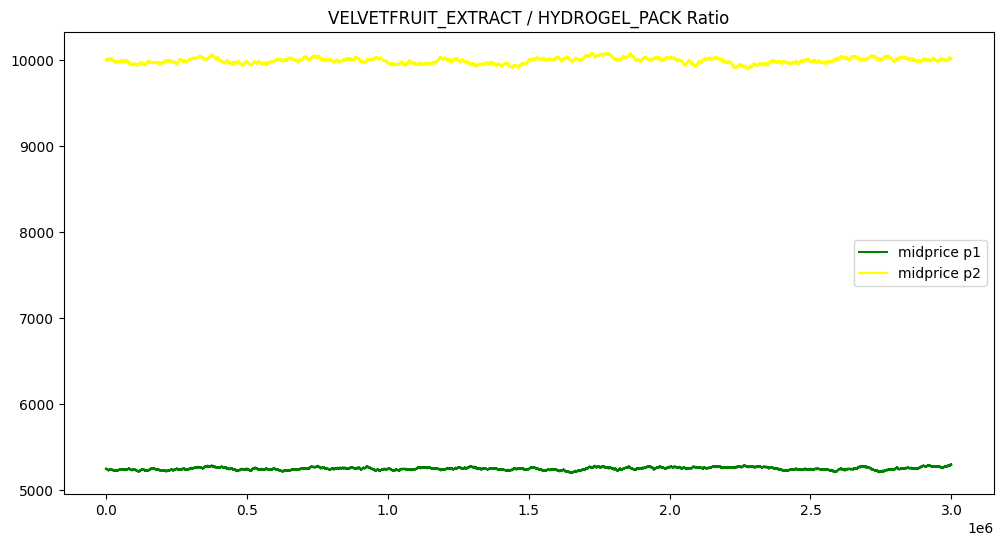

In [199]:
fig, ax = plt.subplots(figsize=(12, 6))

# 3. Calculate the ratio using the aligned mid_prices
merged['ratio'] = merged['mid_price_1'] / merged['mid_price_2']

# 4. Plot using the common timestamps
ax.plot(merged['timestamp'], merged['mid_price_1'], color="green", label="midprice p1")
ax.plot(merged['timestamp'], merged['mid_price_2'], color="yellow", label="midprice p2")


plt.legend()
plt.title(f"{p1['product'].iloc[0]} / {p2['product'].iloc[0]} Ratio")
plt.show()

In [125]:
def diff(beta):
    return np.sum(merged['mid_price_1'] - beta * merged['mid_price_2'])**2

In [136]:
diff(0.5254945494549456)

np.float64(212425.12799611673)

In [135]:
values_to_test = np.linspace(0.5, 0.54, 10000)
min_diff = np.inf
best_beta = 0
for value in values_to_test:
    dif = diff(value)
    if dif < min_diff:
        min_diff = dif
        best_beta = value
    
print(best_beta)

0.5254945494549456


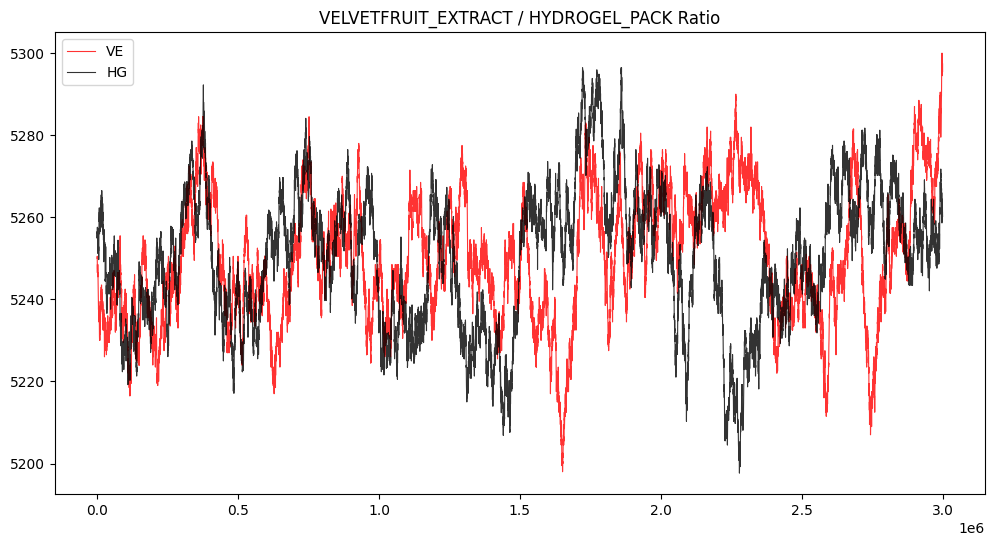

In [152]:
fig, ax = plt.subplots(figsize=(12, 6))

# 3. Calculate the ratio using the aligned mid_prices
merged['ratio'] = merged['mid_price_1'] / merged['mid_price_2']

# 4. Plot using the common timestamps
ax.plot(merged['timestamp'], merged['mid_price_1'], color="red", lw=0.8, alpha=0.8, label="VE")
ax.plot(merged['timestamp'], best_beta * merged['mid_price_2'], color="black", lw=0.8, alpha=0.8, label="HG")


plt.legend()
plt.title(f"{p1['product'].iloc[0]} / {p2['product'].iloc[0]} Ratio")
plt.show()

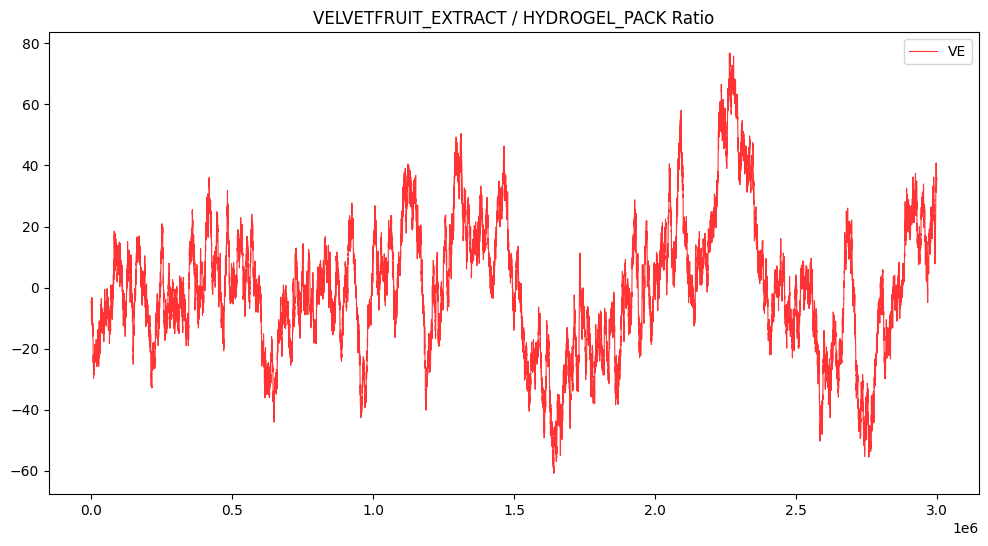

In [174]:
fig, ax = plt.subplots(figsize=(12, 6))

# 3. Calculate the ratio using the aligned mid_prices
merged['ratio'] = merged['mid_price_1'] / merged['mid_price_2']

# 4. Plot using the common timestamps
ax.plot(merged['timestamp'], merged['mid_price_1']-best_beta * merged['mid_price_2'], color="red", lw=0.8, alpha=0.8, label="VE")


plt.legend()
plt.title(f"{p1['product'].iloc[0]} / {p2['product'].iloc[0]} Ratio")
plt.show()

In [146]:
import pandas as pd
import numpy as np
from statsmodels.tsa.stattools import adfuller

def check_cointegration_adf(df, beta):
    """
    Calculates the spread and performs the ADF test.
    """
    # 1. Calculate the spread based on your best_beta
    # Formula: Spread = Price1 - (Beta * Price2)
    df['spread'] = df['mid_price_1'] - (beta * df['mid_price_2'])
    
    # 2. Run the ADF Test
    # we use 'c' for a constant trend (intercept)
    result = adfuller(df['spread'], autolag='AIC')
    
    # 3. Extract results
    test_statistic = result[0]
    p_value = result[1]
    critical_values = result[4]
    
    print("--- ADF Test Results ---")
    print(f"ADF Statistic: {test_statistic:.4f}")
    print(f"p-value: {p_value:.4e}")
    print("Critical Values:")
    for key, value in critical_values.items():
        print(f"   {key}: {value:.4f}")
    
    # 4. Interpretation Logic
    if p_value < 0.05:
        print("\nResult: [SUCCESS] The spread is Stationary (p < 0.05).")
        print("The pair is likely cointegrated and suitable for Mean Reversion.")
    else:
        print("\nResult: [FAILURE] The spread is Non-Stationary (p >= 0.05).")
        print("The relationship might be drifting; trading this could be risky.")

# Example Usage (assuming 'merged' is your dataframe and 'best_beta' is defined)
check_cointegration_adf(merged, best_beta)

--- ADF Test Results ---
ADF Statistic: -5.3118
p-value: 5.1763e-06
Critical Values:
   1%: -3.4306
   5%: -2.8616
   10%: -2.5668

Result: [SUCCESS] The spread is Stationary (p < 0.05).
The pair is likely cointegrated and suitable for Mean Reversion.


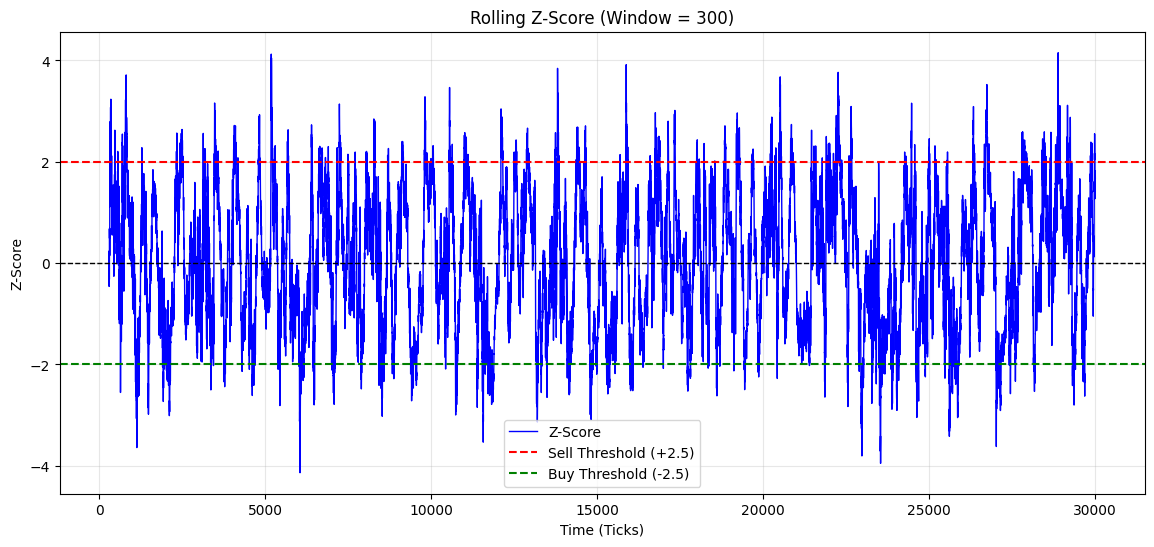

In [148]:
spread = merged['mid_price_1'] - best_beta * merged['mid_price_2']
window = 300

rolling_mean = spread.rolling(window=window).mean()
rolling_std = spread.rolling(window=window).std()

# 3. Calculate the rolling Z-score
# Formula: (Current Spread - Rolling Mean) / Rolling Std
merged['z_score'] = (spread - rolling_mean) / rolling_std

# 4. Plotting the Z-score over time
plt.figure(figsize=(14, 6))
plt.plot(merged.index, merged['z_score'], label='Z-Score', color='blue', linewidth=1)

# Add horizontal lines for your trading thresholds (e.g., +2.5 and -2.5)
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.axhline(2.0, color='red', linestyle='--', label='Sell Threshold (+2.5)')
plt.axhline(-2.0, color='green', linestyle='--', label='Buy Threshold (-2.5)')

plt.title('Rolling Z-Score (Window = 300)')
plt.xlabel('Time (Ticks)')
plt.ylabel('Z-Score')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

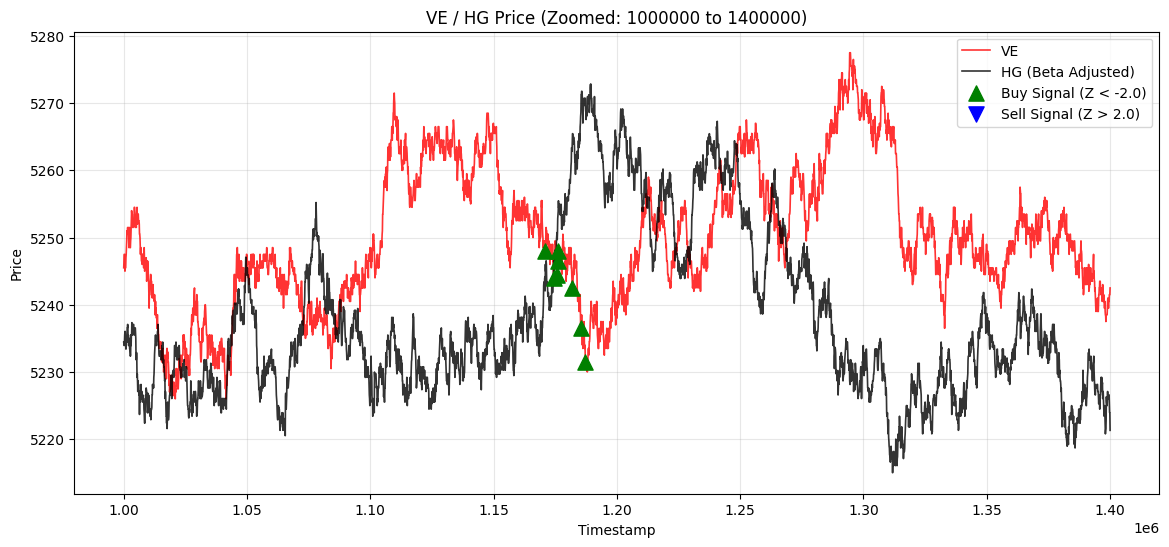

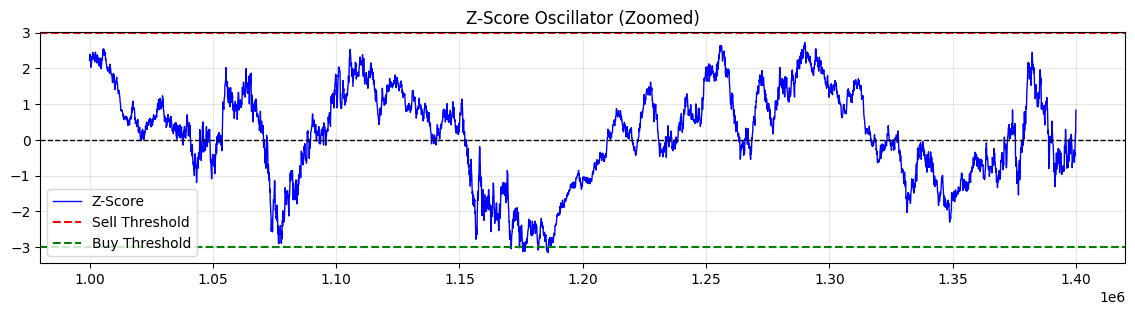

In [173]:
import matplotlib.pyplot as plt

# 1. Calculate the spread and Z-score on the FULL dataset first
spread = merged['mid_price_1'] - best_beta * merged['mid_price_2']
window = 600

rolling_mean = spread.rolling(window=window).mean()
rolling_std = spread.rolling(window=window).std()
merged['z_score'] = (spread - rolling_mean) / rolling_std

# ==========================================
# 2. DEFINE YOUR ZOOM WINDOW HERE
# ==========================================
plot_size = 400000
plot_start = 1000000
min_timestamp = max(window*100, plot_start)  # Change this to your desired start time
max_timestamp = plot_start + plot_size  # Change this to your desired end time

# 3. Create a sliced dataframe just for plotting
plot_df = merged[(merged['timestamp'] >= min_timestamp) & (merged['timestamp'] <= max_timestamp)].copy()

z_score_marker = 3.0
# 4. Find exact entry points using the SLICED dataframe
buy_entries = plot_df[(plot_df['z_score'] < -z_score_marker) & (plot_df['z_score'].shift(1) >= -z_score_marker)]
sell_entries = plot_df[(plot_df['z_score'] > z_score_marker) & (plot_df['z_score'].shift(1) <= z_score_marker)]

# 5. Plotting the zoomed-in view
fig, ax = plt.subplots(figsize=(14, 6))

# Plot the prices
ax.plot(plot_df['timestamp'], plot_df['mid_price_1'], color="red", lw=1.2, alpha=0.8, label="VE")
ax.plot(plot_df['timestamp'], best_beta * plot_df['mid_price_2'], color="black", lw=1.2, alpha=0.8, label="HG (Beta Adjusted)")

# Add the entry signals
ax.scatter(buy_entries['timestamp'], buy_entries['mid_price_1'], 
           marker='^', color='green', s=120, label='Buy Signal (Z < -2.0)', zorder=5)

ax.scatter(sell_entries['timestamp'], sell_entries['mid_price_1'], 
           marker='v', color='blue', s=120, label='Sell Signal (Z > 2.0)', zorder=5)

plt.legend()
plt.title(f"VE / HG Price (Zoomed: {min_timestamp} to {max_timestamp})")
plt.xlabel("Timestamp")
plt.ylabel("Price")
plt.grid(True, alpha=0.3)
plt.show()

# Optional: Plot the Z-score for the exact same zoomed-in window underneath
plt.figure(figsize=(14, 3))
plt.plot(plot_df['timestamp'], plot_df['z_score'], label='Z-Score', color='blue', linewidth=1)
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.axhline(z_score_marker, color='red', linestyle='--', label='Sell Threshold')
plt.axhline(-z_score_marker, color='green', linestyle='--', label='Buy Threshold')
plt.title('Z-Score Oscillator (Zoomed)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

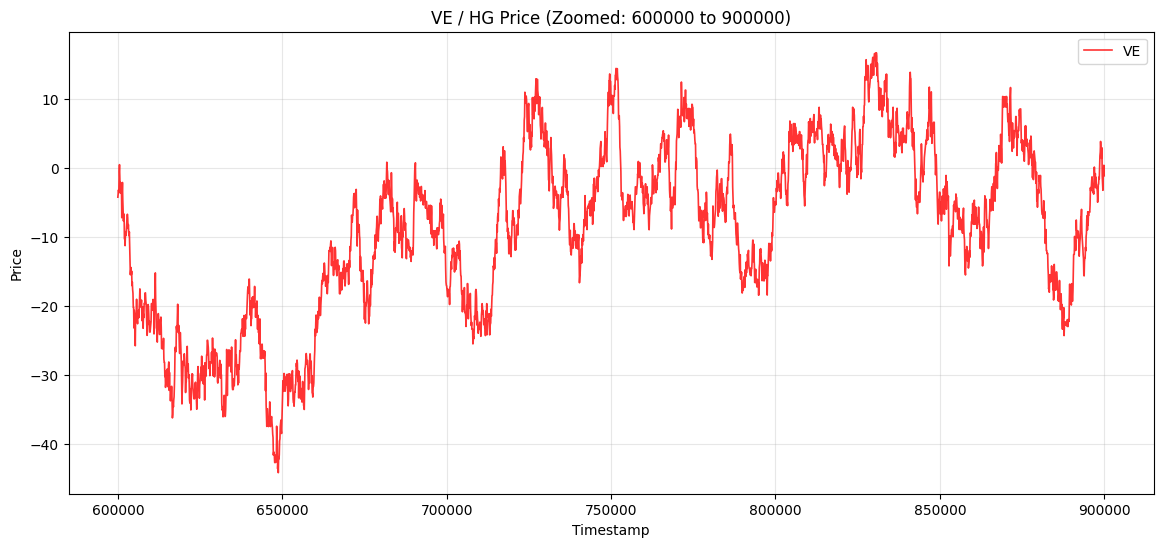

In [172]:
fig, ax = plt.subplots(figsize=(14, 6))

# Plot the prices
ax.plot(plot_df['timestamp'], plot_df['mid_price_1']-best_beta * plot_df['mid_price_2'], color="red", lw=1.2, alpha=0.8, label="VE")


# # Add the entry signals
# ax.scatter(buy_entries['timestamp'], buy_entries['mid_price_1'], 
#            marker='^', color='green', s=120, label='Buy Signal (Z < -2.0)', zorder=5)

# ax.scatter(sell_entries['timestamp'], sell_entries['mid_price_1'], 
#            marker='v', color='blue', s=120, label='Sell Signal (Z > 2.0)', zorder=5)

plt.legend()
plt.title(f"VE / HG Price (Zoomed: {min_timestamp} to {max_timestamp})")
plt.xlabel("Timestamp")
plt.ylabel("Price")
plt.grid(True, alpha=0.3)
plt.show()